In [ ]:
import os
os.chdir('content/MyDrive')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [ ]:
def f(x):
    # x shape: (2,)
    return np.array([x[0]**3, x[1]**3])

def g(x):
    # identity matrix
    return np.eye(2)

def Q(x):
    return x[0]**2 + x[1]**2 + 2*(x[0]**4 + x[1]**4)

R = np.eye(2)
R_inv = np.eye(2)

In [ ]:
def V_true(x):
    return (
        0.5*x[0]**4 + 0.5*(x[0]**2 + 1)**2 - 0.5
        + 0.5*x[1]**4 + 0.5*(x[1]**2 + 1)**2 - 0.5
    )

In [ ]:
def kappa_0(x):
    return -x

In [ ]:
def act(z):
    return np.tanh(z)

def act_prime(z):
    return 1.0 - np.tanh(z)**2

In [ ]:
def sample_points(N, low=-1.0, high=1.0):
    return np.random.uniform(low, high, size=(N, 2))

In [ ]:
def ghjb_residual(x, beta, W, b, kappa):
    """
    x: (2,)
    W: (m, 2)
    b: (m,)
    beta: (m,)
    """

    z = W @ x + b              # (m,)
    phi = act(z)                # (m,)
    phi_p = act_prime(z)

    # gradient of V: shape (2,)
    gradV = (beta * phi_p) @ W

    u = kappa(x)               # (2,)

    return (
        Q(x)
        + u.T @ R @ u
        + gradV @ (f(x) + g(x) @ u)
    )

In [ ]:
def solve_beta(xs, W, b, kappa, lam=1e-6):
    N, n = xs.shape
    m = W.shape[0]

    A = np.zeros((N + 1, m))
    y = np.zeros(N + 1)

    for i, x in enumerate(xs):
        z = W @ x + b
        sigma_p = act_prime(z)

        # ∇V basis: (m, 2)
        gradV_basis = sigma_p[:, None] * W

        u = kappa(x)

        # contraction with dynamics
        A[i, :] = gradV_basis @ (f(x) + g(x) @ u)
        y[i] = -(Q(x) + u.T @ R @ u)

    # boundary condition V(0) = 0
    A[N, :] = act(b)
    y[N] = 0.0

    beta = np.linalg.lstsq(
        A.T @ A + lam * np.eye(m),
        A.T @ y,
        rcond=None
    )[0]

    return beta

In [ ]:
def V_hat(x, beta, W, b):
    return beta @ act(W @ x + b)

def gradV_hat(x, beta, W, b):
    z = W @ x + b
    return (beta * act_prime(z)) @ W

def kappa_hat(x, beta, W, b):
    return -0.5 * gradV_hat(x, beta, W, b)

def ghjb_residual(x, beta, W, b):
    u = kappa_hat(x, beta, W, b)
    return (
        Q(x)
        + u @ R @ u
        + gradV_hat(x, beta, W, b) @ (f(x) + g(x) @ u)
    )

In [ ]:
grid_n = 60
x1 = np.linspace(-1.0, 1.0, grid_n)
x2 = np.linspace(-1.0, 1.0, grid_n)

X1, X2 = np.meshgrid(x1, x2)
grid_pts = np.stack([X1.ravel(), X2.ravel()], axis=1)

In [ ]:
def improve_policy(beta, W, b):
    def kappa_new(x):
        z = W @ x + b
        sigma_p = act_prime(z)
        gradV = (beta * sigma_p) @ W
        return -0.5 * gradV
    return kappa_new

In [ ]:
m = 500     # hidden units
N = 8000     # collocation points
iters = 50

W = np.random.randn(m, 2) * 0.5
b = np.random.randn(m) * 0.5

kappa = kappa_0

for i in range(iters):
    xs = sample_points(N)
    beta = solve_beta(xs, W, b, kappa)
    kappa = improve_policy(beta, W, b)
    print(f"Iteration {i+1} done")

Iteration 1 done
Iteration 2 done
Iteration 3 done
Iteration 4 done
Iteration 5 done
Iteration 6 done
Iteration 7 done
Iteration 8 done
Iteration 9 done
Iteration 10 done
Iteration 11 done
Iteration 12 done
Iteration 13 done
Iteration 14 done
Iteration 15 done
Iteration 16 done
Iteration 17 done
Iteration 18 done
Iteration 19 done
Iteration 20 done
Iteration 21 done
Iteration 22 done
Iteration 23 done
Iteration 24 done
Iteration 25 done
Iteration 26 done
Iteration 27 done
Iteration 28 done
Iteration 29 done
Iteration 30 done
Iteration 31 done
Iteration 32 done
Iteration 33 done
Iteration 34 done
Iteration 35 done
Iteration 36 done
Iteration 37 done
Iteration 38 done
Iteration 39 done
Iteration 40 done
Iteration 41 done
Iteration 42 done
Iteration 43 done
Iteration 44 done
Iteration 45 done
Iteration 46 done
Iteration 47 done
Iteration 48 done
Iteration 49 done
Iteration 50 done


In [ ]:
V_grid = np.array([V_hat(x, beta, W, b) for x in grid_pts])
V_grid = V_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, V_grid, levels=30)
plt.colorbar()
plt.title("Learned Value Function $V(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

NameError: name 'beta' is not defined

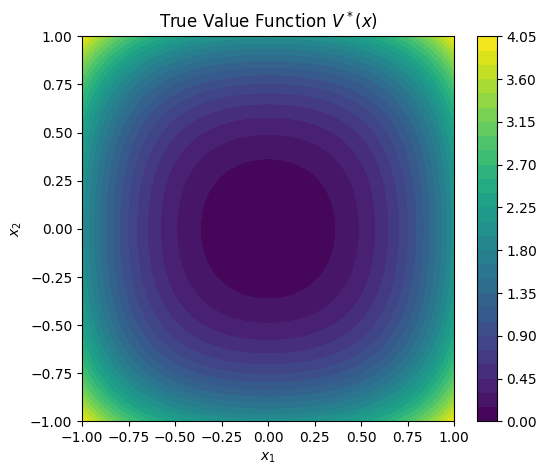

In [ ]:
V_true_grid = np.array([V_true(x) for x in grid_pts])
V_true_grid = V_true_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, V_true_grid, levels=30)
plt.colorbar()
plt.title("True Value Function $V^*(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

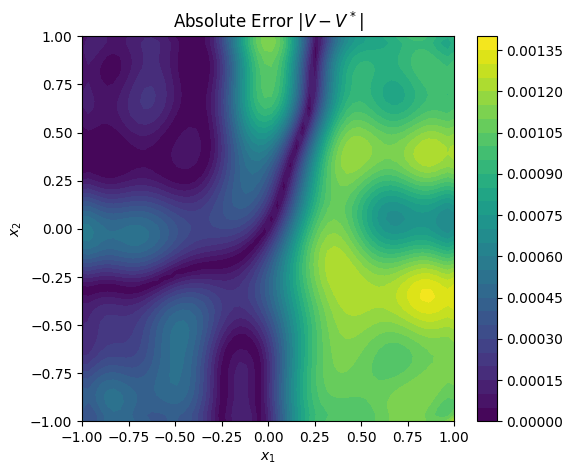

In [ ]:
err_grid = np.abs(V_grid - V_true_grid)

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, err_grid, levels=30)
plt.colorbar()
plt.title("Absolute Error $|V - V^*|$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

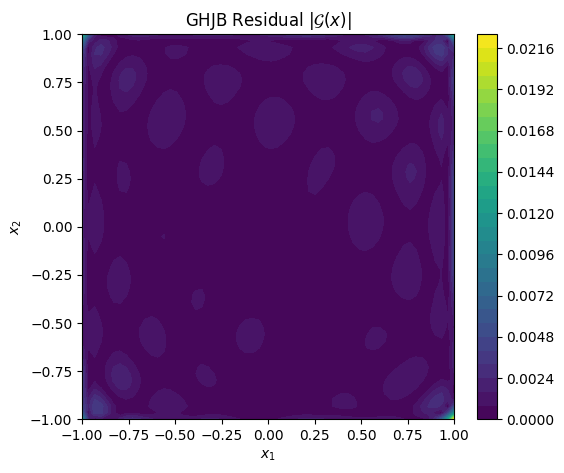

In [ ]:
res_grid = np.array([ghjb_residual(x, beta, W, b) for x in grid_pts])
res_grid = res_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, np.abs(res_grid), levels=30)
plt.colorbar()
plt.title("GHJB Residual $|\\mathcal{G}(x)|$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

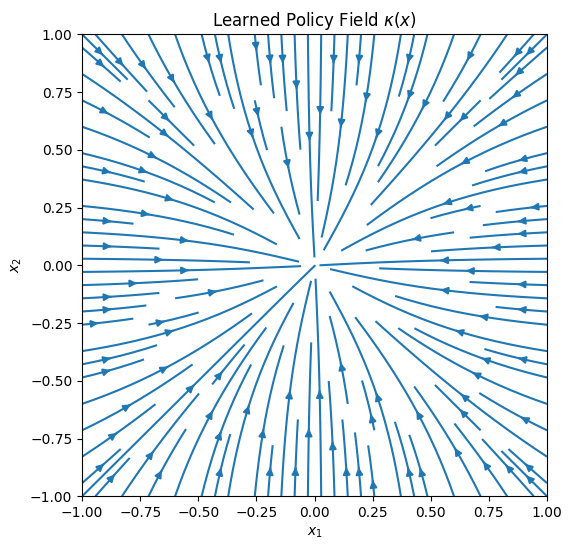

In [ ]:
U = np.zeros_like(X1)
V = np.zeros_like(X2)

for i in range(grid_n):
    for j in range(grid_n):
        u = kappa_hat(np.array([X1[i,j], X2[i,j]]), beta, W, b)
        U[i,j], V[i,j] = u

plt.figure(figsize=(6,6))
plt.streamplot(X1, X2, U, V, density=1.2)
plt.title("Learned Policy Field $\\kappa(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

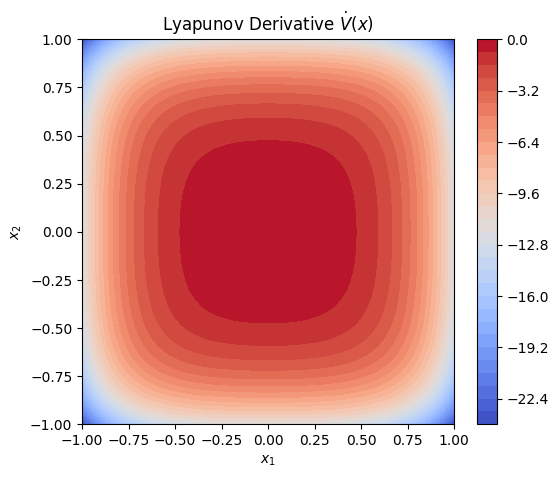

In [ ]:
# reuse the same diagnostic grid
Vdot_grid = np.zeros_like(X1)

for i in range(grid_n):
    for j in range(grid_n):
        x = np.array([X1[i, j], X2[i, j]])
        gradV = gradV_hat(x, beta, W, b)
        u = kappa_hat(x, beta, W, b)
        dx = f(x) + g(x) @ u
        Vdot_grid[i, j] = gradV @ dx
plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, Vdot_grid, levels=30, cmap="coolwarm")
plt.colorbar(cs)
plt.title(r"Lyapunov Derivative $\dot V(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

In [ ]:
def V_hat(x, beta, W, b):
    return beta @ act(W @ x + b)

test_pts = sample_points(2000)
err = np.mean([
    abs(V_hat(x, beta, W, b) - V_true(x))
    for x in test_pts
])

print("Mean absolute error:", err)

Mean absolute error: 0.0005693757390333426


PINN-PI

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def f(x):
    return torch.stack([x[:,0]**3, x[:,1]**3], dim=1)

def Q(x):
    return x[:,0]**2 + x[:,1]**2 + 2*(x[:,0]**4 + x[:,1]**4)

R = torch.eye(2, device=device)
R_inv = torch.eye(2, device=device)

In [ ]:
def kappa_0(x):
    return -x

In [ ]:
class ValueNet(nn.Module):
    def __init__(self, width=500):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
def sample_points(N, low=-1.0, high=1.0):
    x = np.random.uniform(low, high, size=(N,2))
    return torch.tensor(x, dtype=torch.float32, device=device)

In [ ]:
def ghjb_residual(model, x, kappa_fn):
    x.requires_grad_(True)

    V = model(x)
    gradV = torch.autograd.grad(
        V.sum(), x, create_graph=True
    )[0]

    u = kappa_fn(x).detach()
    fx = f(x)

    residual = (
        Q(x)
        + torch.sum(u * u, dim=1)
        + torch.sum(gradV * (fx + u), dim=1)
    )
    return residual

In [ ]:
def improve_policy(model):
    def kappa(x):
        x.requires_grad_(True)
        V = model(x)
        gradV = torch.autograd.grad(
            V.sum(), x, create_graph=False
        )[0]
        return -0.5 * gradV
    return kappa

In [ ]:
def train_value_net(model, kappa_fn, epochs=2000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        x = sample_points(8000)
        res = ghjb_residual(model, x, kappa_fn)
        x0 = torch.zeros(1,2, device=device)
        V0= model(x0)
        bc_loss = V0.pow(2)
        loss = torch.mean(res**2) + 10*bc_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if ep % 200 == 0:
            print(f"Epoch {ep}, GHJB loss {loss.item():.4e}")

In [ ]:
model = ValueNet(width=500).to(device)
kappa = kappa_0

for i in range(50):
    print(f"\n=== Policy Iteration {i+1} ===")
    train_value_net(model, kappa, epochs=300, lr=1e-3)
    kappa = improve_policy(model)


=== Policy Iteration 1 ===
Epoch 0, GHJB loss 7.1486e+00
Epoch 200, GHJB loss 4.5803e+00

=== Policy Iteration 2 ===
Epoch 0, GHJB loss 4.4259e+00
Epoch 200, GHJB loss 1.2549e-02

=== Policy Iteration 3 ===
Epoch 0, GHJB loss 5.1980e-03
Epoch 200, GHJB loss 2.2369e-03

=== Policy Iteration 4 ===
Epoch 0, GHJB loss 1.6929e-03
Epoch 200, GHJB loss 1.0116e-03

=== Policy Iteration 5 ===
Epoch 0, GHJB loss 7.1285e-04
Epoch 200, GHJB loss 4.5793e-04

=== Policy Iteration 6 ===
Epoch 0, GHJB loss 3.8949e-04
Epoch 200, GHJB loss 4.3218e-04

=== Policy Iteration 7 ===
Epoch 0, GHJB loss 4.0744e-04
Epoch 200, GHJB loss 2.7620e-04

=== Policy Iteration 8 ===
Epoch 0, GHJB loss 2.2096e-04
Epoch 200, GHJB loss 2.2158e-04

=== Policy Iteration 9 ===
Epoch 0, GHJB loss 1.8308e-04
Epoch 200, GHJB loss 2.4749e-04

=== Policy Iteration 10 ===
Epoch 0, GHJB loss 1.9835e-04
Epoch 200, GHJB loss 3.9444e-04

=== Policy Iteration 11 ===
Epoch 0, GHJB loss 2.9411e-04
Epoch 200, GHJB loss 3.7401e-04

=== Pol

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

def V_hat(x):
    with torch.no_grad():
        return model(x).cpu().numpy()

def gradV_hat(x):
    x = x.clone().detach().requires_grad_(True)
    V = model(x)
    gradV = torch.autograd.grad(V.sum(), x)[0]
    return gradV

def kappa_hat(x):
    return -0.5 * gradV_hat(x)

def ghjb_residual(x):
    x = x.clone().detach().requires_grad_(True)
    V = model(x)
    gradV = torch.autograd.grad(V.sum(), x)[0]

    u = -0.5 * gradV.detach()
    fx = f(x)

    res = (
        Q(x)
        + torch.sum(u * u, dim=1)
        + torch.sum(gradV * (fx + u), dim=1)
    )
    return res.detach()

In [ ]:
grid_n = 80
x1 = np.linspace(-1.0, 1.0, grid_n)
x2 = np.linspace(-1.0, 1.0, grid_n)
X1, X2 = np.meshgrid(x1, x2)

grid_pts = torch.tensor(
    np.stack([X1.ravel(), X2.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

In [ ]:
with torch.no_grad():
    V0 = model(torch.zeros(1,2, device=device)).item()

V_grid_shifted = V_grid - V0

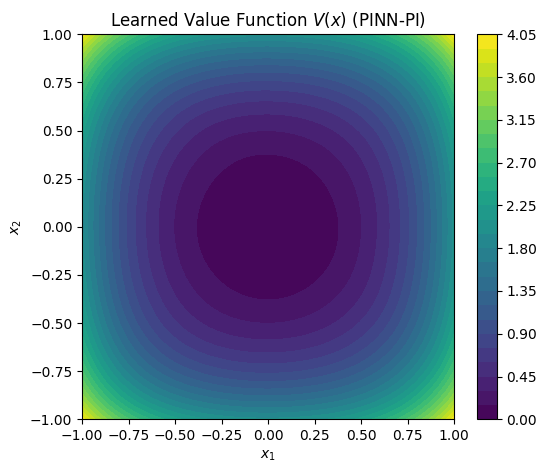

In [ ]:
V_grid = V_hat(grid_pts).reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, V_grid, levels=30)
plt.colorbar(cs)
plt.title("Learned Value Function $V(x)$ (PINN-PI)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

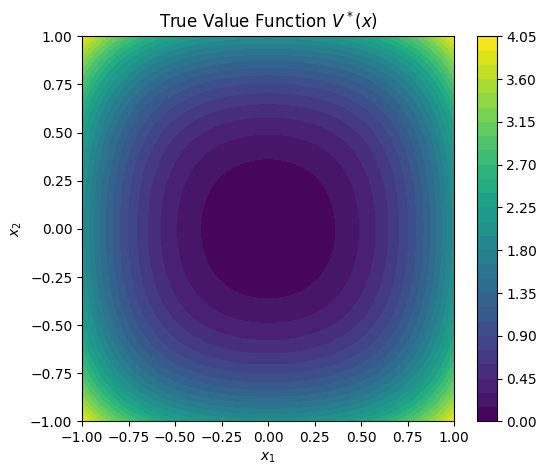

In [ ]:
def V_true(x):
    return (
        0.5*x[:,0]**4 + 0.5*(x[:,0]**2 + 1)**2 - 0.5
        + 0.5*x[:,1]**4 + 0.5*(x[:,1]**2 + 1)**2 - 0.5
    )

V_true_grid = V_true(grid_pts.cpu()).numpy().reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, V_true_grid, levels=30)
plt.colorbar(cs)
plt.title("True Value Function $V^*(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

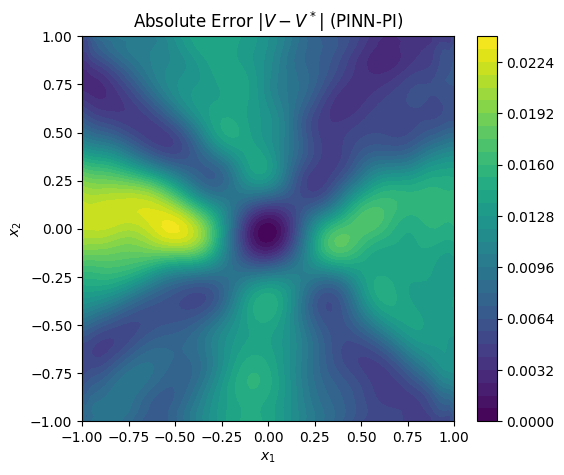

In [ ]:
err_grid = np.abs(V_grid - V_true_grid)

plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, err_grid, levels=30)
plt.colorbar(cs)
plt.title("Absolute Error $|V - V^*|$ (PINN-PI)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

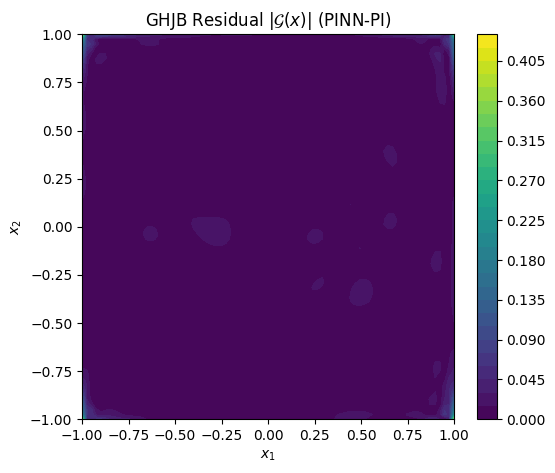

In [ ]:
res_grid = ghjb_residual(grid_pts).cpu().numpy().reshape(grid_n, grid_n)

plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, np.abs(res_grid), levels=30)
plt.colorbar(cs)
plt.title("GHJB Residual $|\\mathcal{G}(x)|$ (PINN-PI)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

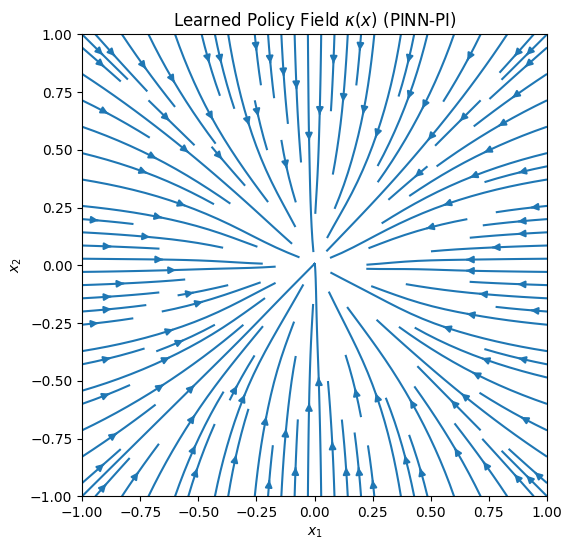

In [ ]:
U = np.zeros_like(X1)
V = np.zeros_like(X2)

# Removed with torch.no_grad():
for i in range(grid_n):
    for j in range(grid_n):
        x = torch.tensor([[X1[i,j], X2[i,j]]],
                         dtype=torch.float32,
                         device=device,
                         requires_grad=True) # Added requires_grad=True
        u = kappa_hat(x)[0].cpu().numpy()
        U[i,j], V[i,j] = u

plt.figure(figsize=(6,6))
plt.streamplot(X1, X2, U, V, density=1.2)
plt.title("Learned Policy Field $\\kappa(x)$ (PINN-PI)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

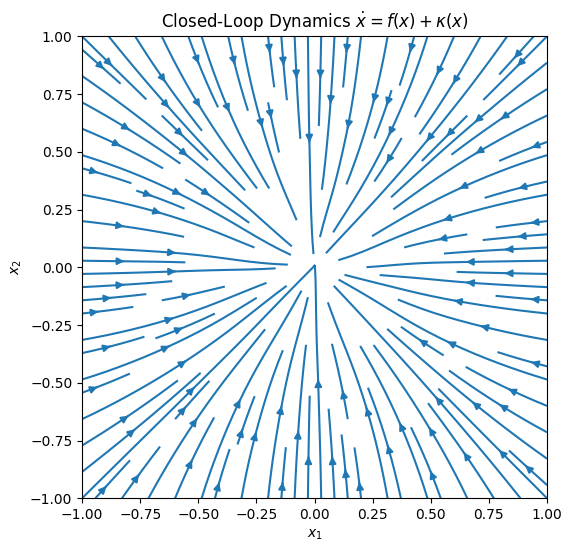

In [ ]:
DX1 = np.zeros_like(X1)
DX2 = np.zeros_like(X2)

# Removed with torch.no_grad():
for i in range(grid_n):
    for j in range(grid_n):
        x = torch.tensor([[X1[i,j], X2[i,j]]],
                         dtype=torch.float32,
                         device=device,
                         requires_grad=True)
        u = kappa_hat(x)[0] # Removed .detach() since kappa_hat handles gradV_hat(x)
        dx = f(x)[0] + u
        DX1[i,j], DX2[i,j] = dx.detach().cpu().numpy()

plt.figure(figsize=(6,6))
plt.streamplot(X1, X2, DX1, DX2, density=1.2)
plt.title("Closed-Loop Dynamics $\\dot x = f(x) + \\kappa(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

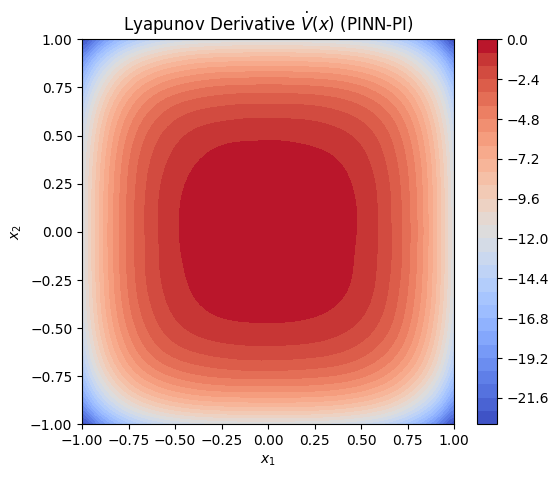

In [ ]:
Vdot_grid = np.zeros_like(X1)

# Ensure gradients are enabled for this block
original_grad_enabled = torch.is_grad_enabled()
torch.set_grad_enabled(True)

for i in range(grid_n):
    for j in range(grid_n):
        x = torch.tensor([[X1[i,j], X2[i,j]]],
                         dtype=torch.float32,
                         device=device,
                         requires_grad=True)
        V = model(x)
        gradV = torch.autograd.grad(V.sum(), x, create_graph=True)[0]
        u = -0.5 * gradV
        dx = f(x) + u
        Vdot_grid[i,j] = (gradV * dx).sum().detach().cpu().numpy()

# Restore original grad enabled state
torch.set_grad_enabled(original_grad_enabled)

plt.figure(figsize=(6,5))
cs = plt.contourf(X1, X2, Vdot_grid, levels=30, cmap="coolwarm")
plt.colorbar(cs)
plt.title(r"Lyapunov Derivative $\dot V(x)$ (PINN-PI)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

Inverse Pendulum Problem

In [ ]:
g = 9.81
l = 1.0
m = 1.0

In [ ]:
def f(x):
    theta = x[:,0]
    omega = x[:,1]
    return torch.stack([
        omega,
        (g / l) * torch.sin(theta)
    ], dim=1)

def g_mat(x):
    B = torch.zeros((x.shape[0], 2, 1), device=x.device)
    B[:,1,0] = 1.0 / (m * l * l)
    return B

In [ ]:
def Q(x):
    return x[:,0]**2 + 0.1 * x[:,1]**2

R = torch.tensor([[0.01]], device=device)
R_inv = torch.inverse(R)

In [ ]:
import scipy.linalg

A = np.array([[0, 1],
              [g/l, 0]])

B = np.array([[0],
              [1/(m*l*l)]])

Q_lqr = np.diag([1.0, 0.1])
R_lqr = np.array([[0.01]])

P = scipy.linalg.solve_continuous_are(A, B, Q_lqr, R_lqr)
K = np.linalg.inv(R_lqr) @ B.T @ P

K = torch.tensor(K, dtype=torch.float32, device=device)

def kappa_0(x):
    return -(x @ K.T)

In [ ]:
class ValueNet(nn.Module):
    def __init__(self, width=500):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
def ghjb_residual(model, x, kappa_fn):
    x.requires_grad_(True)

    V = model(x)
    gradV = torch.autograd.grad(V.sum(), x, create_graph=True)[0]

    u = kappa_fn(x).detach()
    fx = f(x)
    gx = g_mat(x).squeeze(-1)

    res = (
        Q(x)
        + torch.sum(u * (R @ u.unsqueeze(-1)).squeeze(-1), dim=1)
        + torch.sum(gradV * (fx + gx * u), dim=1)
    )
    return res

In [ ]:
def improve_policy(model):
    def kappa(x):
        x.requires_grad_(True)
        V = model(x)
        gradV = torch.autograd.grad(V.sum(), x)[0]
        return -0.5 * (gradV[:,1:2] @ R_inv)
    return kappa

In [ ]:
def sample_points(N):
    theta = np.random.uniform(-np.pi, np.pi, size=N)
    omega = np.random.uniform(-4, 4, size=N)
    x = np.stack([theta, omega], axis=1)
    return torch.tensor(x, dtype=torch.float32, device=device)

model = ValueNet(width=500).to(device)
kappa = kappa_0

for i in range(50):
    print(f"\n=== Policy Iteration {i+1} ===")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(300):
        x = sample_points(8000)
        res = ghjb_residual(model, x, kappa)

        # anchor V(0)=0
        x0 = torch.zeros(1,2, device=device)
        bc = model(x0).pow(2)

        loss = torch.mean(res**2) + 10.0 * bc
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    kappa = improve_policy(model)


=== Policy Iteration 1 ===

=== Policy Iteration 2 ===

=== Policy Iteration 3 ===

=== Policy Iteration 4 ===

=== Policy Iteration 5 ===

=== Policy Iteration 6 ===

=== Policy Iteration 7 ===

=== Policy Iteration 8 ===

=== Policy Iteration 9 ===

=== Policy Iteration 10 ===

=== Policy Iteration 11 ===

=== Policy Iteration 12 ===

=== Policy Iteration 13 ===

=== Policy Iteration 14 ===

=== Policy Iteration 15 ===

=== Policy Iteration 16 ===

=== Policy Iteration 17 ===

=== Policy Iteration 18 ===

=== Policy Iteration 19 ===

=== Policy Iteration 20 ===

=== Policy Iteration 21 ===

=== Policy Iteration 22 ===

=== Policy Iteration 23 ===

=== Policy Iteration 24 ===

=== Policy Iteration 25 ===

=== Policy Iteration 26 ===

=== Policy Iteration 27 ===

=== Policy Iteration 28 ===

=== Policy Iteration 29 ===

=== Policy Iteration 30 ===

=== Policy Iteration 31 ===

=== Policy Iteration 32 ===

=== Policy Iteration 33 ===

=== Policy Iteration 34 ===

=== Policy Iteration 3

In [ ]:
def simulate(x0, T=5.0, dt=0.01):
    x = x0.clone()
    traj = [x.cpu().numpy()]

    for _ in range(int(T/dt)):
        u = kappa(x.unsqueeze(0))[0]
        dx = f(x.unsqueeze(0))[0] + g_mat(x.unsqueeze(0))[0,:,0] * u
        x = x + dt * dx
        x[0] = ((x[0] + np.pi) % (2*np.pi)) - np.pi
        traj.append(x.cpu().numpy())

    return np.array(traj)

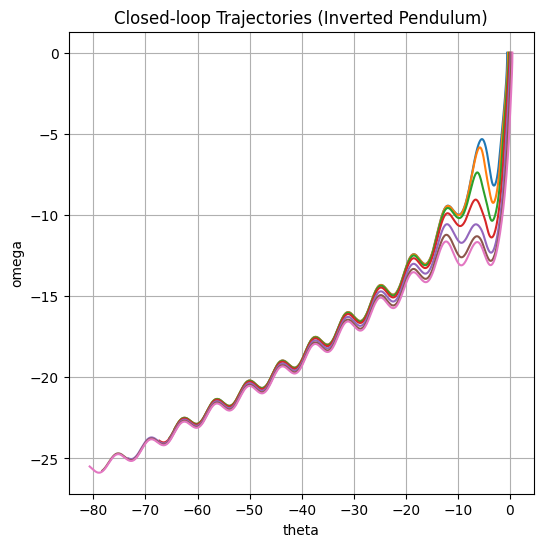

In [ ]:
plt.figure(figsize=(6,6))
for th0 in np.linspace(-0.5, 0.5, 7):
    traj = simulate(torch.tensor([th0, 0.0], device=device, dtype=torch.float32))
    plt.plot(traj[:,0], traj[:,1])
plt.xlabel("theta")
plt.ylabel("omega")
plt.title("Closed-loop Trajectories (Inverted Pendulum)")
plt.grid(True)
plt.show()